# Technical-Analysis Baseline Performance And Rule Visualization

This notebook inspects the deterministic technical-analysis baseline. It visualizes aggregate classification performance and then focuses on one ticker to show how the rule behaves against candlestick price history.

The baseline uses only price features available through the prior trading day. It predicts:

- `positive` when the prior close is near the top of its recent 20-day range and the volatility-adjusted upside signal is strong.
- `negative` when the prior close is near the bottom of its recent 20-day range and the volatility-adjusted downside signal is strong.
- `neutral` otherwise.

In [1]:
from pathlib import Path
import json
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/marketmood-matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.dates as mdates
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, f1_score

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
PREDICTIONS_PATH = PROJECT_ROOT / "outputs" / "predictions" / "ta_baseline_test_predictions.csv"
METRICS_PATH = PROJECT_ROOT / "outputs" / "metrics" / "ta_baseline_metrics.json"
PRICE_DIR = PROJECT_ROOT / "data" / "prices"

SELECTED_TICKER = "TSLA"
CHART_START = "2020-01-01"
CHART_END = "2020-04-30"
LABEL_ORDER = ["negative", "neutral", "positive"]
CLASS_COLORS = {"negative": "#D55E00", "neutral": "#777777", "positive": "#0072B2"}

## Load Baseline Outputs

In [2]:
predictions = pd.read_csv(PREDICTIONS_PATH, parse_dates=["post_date", "event_date"])
with METRICS_PATH.open("r", encoding="utf-8") as file:
    metrics = json.load(file)

summary = pd.Series(
    {
        "rows": metrics["n_rows"],
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
        "weighted_f1": metrics["weighted_f1"],
        "threshold": metrics["threshold"],
        "upper_range": metrics["upper_range"],
        "lower_range": metrics["lower_range"],
    }
).to_frame("value")

summary

,value
rows,994.000000
accuracy,0.475855
macro_f1,0.411737
weighted_f1,0.474912
threshold,0.750000
upper_range,0.800000
lower_range,0.200000


In [3]:
predictions.head()

,id,split,ticker,post_date,event_date,original,true_label,ret_5d,vol_20d,range_position_20d,breakout_strength_20d,breakdown_strength_20d,momentum_score,breakout_score,breakdown_score,predicted_label,prob_negative,prob_neutral,prob_positive
0,109001,test,DIS,2020-01-02,2020-01-02,$DIS when is the shorts squeeze is what I wanna know 🚂🚂🚂🚂🚂 💰,negative,-0.000346,0.007944,0.144465,-0.034016,0.005982,-0.043500,-4.281708,0.752942,neutral,0.0,1.0,0.0
1,109002,test,AAPL,2020-01-03,2020-01-03,"$AAPL I’m out for now!! I don’t think it’ll dip big, but if it does it’ll be nice🍎💰✨",positive,0.056566,0.009311,1.195903,0.022816,0.157641,6.075310,2.450493,16.931050,positive,0.0,0.0,1.0
2,109003,test,PYPL,2020-01-07,2020-01-07,$PYPL Back Over $120+ where this belongs 💰,positive,0.007038,0.011410,0.918654,-0.005237,0.063212,0.616880,-0.459003,5.540242,neutral,0.0,1.0,0.0
3,100067,test,AAPL,2020-01-08,2020-01-08,$AAPL with all time highs again the market seems to enjoy war very much🤔,positive,0.023566,0.009645,0.941371,-0.006526,0.117900,2.443310,-0.676574,12.223852,positive,0.0,0.0,1.0
4,109005,test,BA,2020-01-08,2020-01-08,"$BA Of course there were technical problems behind this crash, just like the other two! How many more planes have to crash before this company gets banned f...",positive,0.033333,0.015559,0.406636,-0.047474,0.035363,2.142328,-3.051135,2.272801,neutral,0.0,1.0,0.0


## Overall Performance

In [4]:
report = pd.DataFrame(metrics["classification_report"]).T
report

,precision,recall,f1-score,support
negative,0.360000,0.227273,0.278638,198.000000
neutral,0.614068,0.599258,0.606573,539.000000
positive,0.306122,0.408560,0.350000,257.000000
accuracy,0.475855,0.475855,0.475855,0.475855
macro avg,0.426730,0.411697,0.411737,994.000000
weighted avg,0.483839,0.475855,0.474912,994.000000


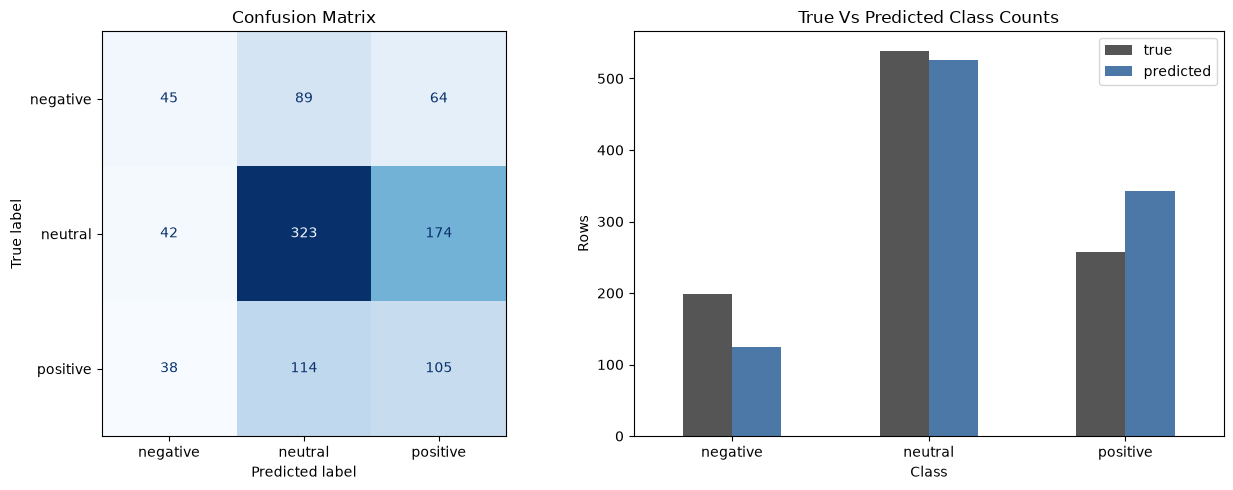

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

matrix = confusion_matrix(
    predictions["true_label"],
    predictions["predicted_label"],
    labels=LABEL_ORDER,
)
ConfusionMatrixDisplay(matrix, display_labels=LABEL_ORDER).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format="d"
)
axes[0].set_title("Confusion Matrix")

distribution = pd.DataFrame(
    {
        "true": predictions["true_label"].value_counts().reindex(LABEL_ORDER),
        "predicted": predictions["predicted_label"].value_counts().reindex(LABEL_ORDER),
    }
)
distribution.plot(kind="bar", ax=axes[1], color=["#555555", "#4C78A8"])
axes[1].set_title("True Vs Predicted Class Counts")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Rows")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()

## Per-Ticker Performance

In [6]:
def ticker_macro_f1(group: pd.DataFrame) -> float:
    return f1_score(group["true_label"], group["predicted_label"], labels=LABEL_ORDER, average="macro", zero_division=0)

ticker_summary = (
    predictions.groupby("ticker")
    .apply(
        lambda group: pd.Series(
            {
                "rows": len(group),
                "accuracy": (group["true_label"] == group["predicted_label"]).mean(),
                "macro_f1": ticker_macro_f1(group),
                "predicted_positive_rate": (group["predicted_label"] == "positive").mean(),
                "predicted_negative_rate": (group["predicted_label"] == "negative").mean(),
            }
        ),
        include_groups=False,
    )
    .sort_values(["rows", "macro_f1"], ascending=[False, False])
)

ticker_summary.head(15).round(3)

,rows,accuracy,macro_f1,predicted_positive_rate,predicted_negative_rate
ticker,,,,,
TSLA,426.0,0.505,0.390,0.413,0.049
AAPL,167.0,0.419,0.426,0.407,0.222
BA,88.0,0.591,0.467,0.193,0.148
DIS,41.0,0.561,0.443,0.073,0.415
AMZN,39.0,0.513,0.350,0.282,0.077
MSFT,35.0,0.200,0.185,0.457,0.029
CCL,33.0,0.424,0.351,0.121,0.273
BABA,28.0,0.500,0.430,0.143,0.286
FB,22.0,0.227,0.189,0.364,0.045


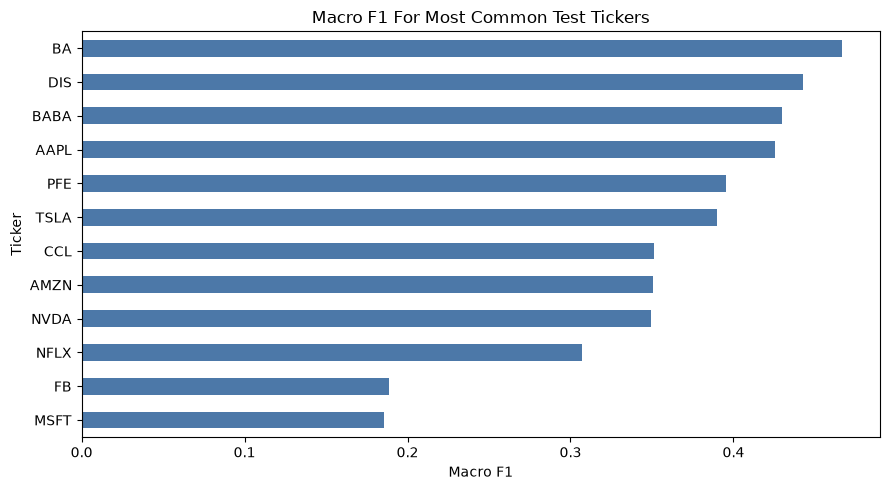

In [7]:
top_tickers = ticker_summary.head(12).sort_values("macro_f1")

fig, ax = plt.subplots(figsize=(9, 5))
top_tickers["macro_f1"].plot(kind="barh", ax=ax, color="#4C78A8")
ax.set_title("Macro F1 For Most Common Test Tickers")
ax.set_xlabel("Macro F1")
ax.set_ylabel("Ticker")
plt.tight_layout()

## Select A Ticker For Rule Visualization

Change `SELECTED_TICKER`, `CHART_START`, and `CHART_END` in the setup cell to inspect a different ticker or date range.

In [8]:
ticker_predictions = predictions.loc[predictions["ticker"].eq(SELECTED_TICKER)].copy()
ticker_predictions = ticker_predictions.sort_values("event_date")

price_path = PRICE_DIR / f"{SELECTED_TICKER}.csv"
prices = pd.read_csv(price_path, parse_dates=["date"])
prices = prices.sort_values("date")

chart_prices = prices.loc[
    prices["date"].between(pd.Timestamp(CHART_START), pd.Timestamp(CHART_END))
].copy()
chart_predictions = ticker_predictions.loc[
    ticker_predictions["event_date"].between(pd.Timestamp(CHART_START), pd.Timestamp(CHART_END))
].copy()

ticker_rule_summary = pd.Series(
    {
        "ticker": SELECTED_TICKER,
        "test_rows": len(ticker_predictions),
        "chart_rows": len(chart_predictions),
        "chart_start": CHART_START,
        "chart_end": CHART_END,
        "ticker_accuracy": (ticker_predictions["true_label"] == ticker_predictions["predicted_label"]).mean(),
        "ticker_macro_f1": ticker_macro_f1(ticker_predictions),
    }
).to_frame("value")

ticker_rule_summary

,value
ticker,TSLA
test_rows,426
chart_rows,143
chart_start,2020-01-01
chart_end,2020-04-30
ticker_accuracy,0.504695
ticker_macro_f1,0.389745


## Candlesticks With Baseline Predictions

Markers show baseline predictions on event dates. Upward triangles are `positive`, downward triangles are `negative`, and small circles are `neutral`. Marker edge color indicates the true class for the generated target.

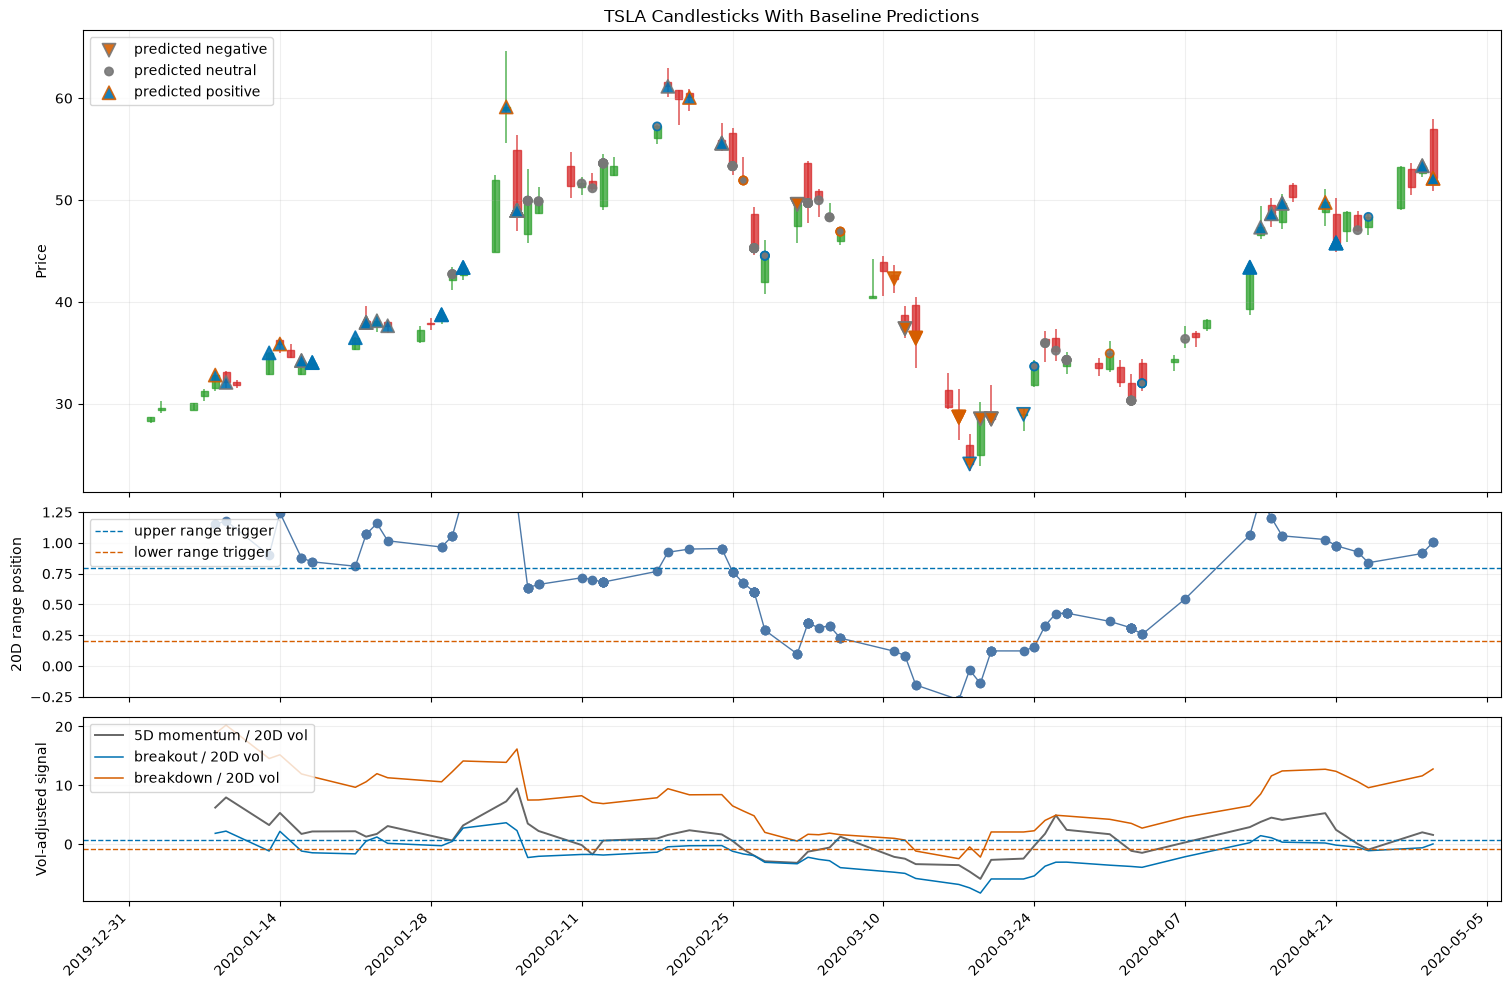

In [9]:
def plot_candlesticks(ax, price_frame: pd.DataFrame, width: float = 0.65) -> None:
    for row in price_frame.itertuples(index=False):
        date_num = mdates.date2num(row.date)
        open_price = row.open
        close_price = row.close
        high_price = row.high
        low_price = row.low
        color = "#2CA02C" if close_price >= open_price else "#D62728"
        lower = min(open_price, close_price)
        height = abs(close_price - open_price)
        ax.vlines(date_num, low_price, high_price, color=color, linewidth=1.1, alpha=0.8)
        body = patches.Rectangle(
            (date_num - width / 2, lower),
            width,
            max(height, 0.01),
            facecolor=color,
            edgecolor=color,
            alpha=0.75,
        )
        ax.add_patch(body)


fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True, gridspec_kw={"height_ratios": [3, 1.2, 1.2]})

plot_candlesticks(axes[0], chart_prices)
axes[0].set_title(f"{SELECTED_TICKER} Candlesticks With Baseline Predictions")
axes[0].set_ylabel("Price")

marker_map = {"positive": "^", "neutral": "o", "negative": "v"}
size_map = {"positive": 90, "neutral": 35, "negative": 90}
price_lookup = chart_prices.set_index("date")["close"]

for label in LABEL_ORDER:
    subset = chart_predictions.loc[chart_predictions["predicted_label"].eq(label)].copy()
    if subset.empty:
        continue
    subset["plot_price"] = subset["event_date"].map(price_lookup)
    subset = subset.dropna(subset=["plot_price"])
    edge_colors = subset["true_label"].map(CLASS_COLORS)
    axes[0].scatter(
        subset["event_date"],
        subset["plot_price"],
        marker=marker_map[label],
        s=size_map[label],
        color=CLASS_COLORS[label],
        edgecolor=edge_colors,
        linewidth=1.2,
        alpha=0.9,
        label=f"predicted {label}",
        zorder=5,
    )

axes[0].legend(loc="upper left")
axes[0].grid(alpha=0.2)

axes[1].plot(chart_predictions["event_date"], chart_predictions["range_position_20d"], color="#4C78A8", marker="o", linewidth=1)
axes[1].axhline(metrics["upper_range"], color="#0072B2", linestyle="--", linewidth=1, label="upper range trigger")
axes[1].axhline(metrics["lower_range"], color="#D55E00", linestyle="--", linewidth=1, label="lower range trigger")
axes[1].set_ylabel("20D range position")
axes[1].set_ylim(-0.25, 1.25)
axes[1].legend(loc="upper left")
axes[1].grid(alpha=0.2)

axes[2].plot(chart_predictions["event_date"], chart_predictions["momentum_score"], color="#666666", label="5D momentum / 20D vol", linewidth=1.4)
axes[2].plot(chart_predictions["event_date"], chart_predictions["breakout_score"], color="#0072B2", label="breakout / 20D vol", linewidth=1.1)
axes[2].plot(chart_predictions["event_date"], chart_predictions["breakdown_score"], color="#D55E00", label="breakdown / 20D vol", linewidth=1.1)
axes[2].axhline(metrics["threshold"], color="#0072B2", linestyle="--", linewidth=1)
axes[2].axhline(-metrics["threshold"], color="#D55E00", linestyle="--", linewidth=1)
axes[2].set_ylabel("Vol-adjusted signal")
axes[2].legend(loc="upper left")
axes[2].grid(alpha=0.2)

axes[2].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

## Rule-Level Examples For Selected Ticker

In [10]:
example_columns = [
    "event_date",
    "ticker",
    "true_label",
    "predicted_label",
    "range_position_20d",
    "momentum_score",
    "breakout_score",
    "breakdown_score",
    "original",
]

ticker_predictions.sort_values("event_date")[example_columns].head(20)

,event_date,ticker,true_label,predicted_label,range_position_20d,momentum_score,breakout_score,breakdown_score,original
5,2020-01-08,TSLA,negative,positive,1.151491,6.214808,1.839586,18.797137,$TSLA I think we ready for that $510 ride Tesla. Yes we are ready. We got our seatbelts on 😂😂🔥🔥 🚀 🚀 🚀 🚀
7,2020-01-09,TSLA,neutral,positive,1.178183,7.943231,2.215178,20.235123,$TSLA the market is giving away money rn and bears refuse it. They prefer the path of greatest resistance. 🤷🏽‍♂️
13,2020-01-13,TSLA,positive,positive,0.899670,3.246194,-1.163363,14.556319,$TSLA when do i buy?? Waaaaaa 😭😭
15,2020-01-14,TSLA,negative,positive,1.244635,5.311035,2.174590,15.192632,$TSLA Realistically I think ER COULD go either way.. I’m thinking of a straddle mostly bearish though because revenue could be abit low.. however straddles ...
20,2020-01-16,TSLA,neutral,positive,0.877808,1.737046,-1.170810,11.938022,$TSLA you may have a gambling problem if you’re buying here. 🤷‍♂️ do as you wish
21,2020-01-16,TSLA,neutral,positive,0.877808,1.737046,-1.170810,11.938022,"$TSLA who called the top here ? When everybody thought was crazy. Me moFos, me ! 🧙‍♂️"
23,2020-01-17,TSLA,positive,positive,0.846285,2.157329,-1.466874,11.462562,$TSLA anyone believes it’ll hit 496$ today ??🤚🏼
24,2020-01-17,TSLA,positive,positive,0.846285,2.157329,-1.466874,11.462562,$TSLA get ready to make an appointment to get in line for your appointment to fix issues Tesla owners 😳
25,2020-01-21,TSLA,positive,positive,0.810596,2.190966,-1.650727,9.666084,$TSLA down 6$ afterhours right now 🤔
29,2020-01-22,TSLA,neutral,positive,1.069316,1.273629,0.516219,10.602307,$TSLA tweet from Ross Gerber. Cool 😎 one🍷🍀🚀🤗


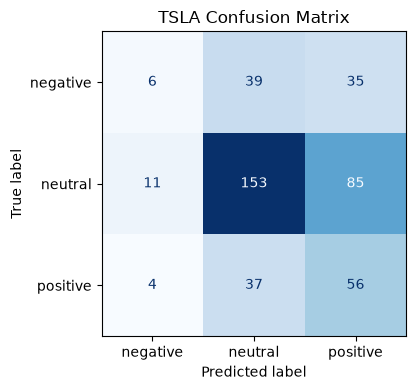

In [11]:
ticker_confusion = confusion_matrix(
    ticker_predictions["true_label"],
    ticker_predictions["predicted_label"],
    labels=LABEL_ORDER,
)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(ticker_confusion, display_labels=LABEL_ORDER).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d"
)
ax.set_title(f"{SELECTED_TICKER} Confusion Matrix")
plt.tight_layout()